## Imports

In [1]:
import os

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

In [ ]:
ADBENCH_DIR = "path/to/ADBench/datasets/dir"

## Utils

### Data

In [3]:
def load_data(filename: str):
    """Load the data from an ADBench file"""
    raw_data = np.load(filename)
    return raw_data["X"], raw_data["y"]

def make_properties(file_dir: str, filename: str):
    """Load the data from an ADBench file, retrieve its properties and assign it the correct categories. """
    # Load data
    X, y = load_data(os.path.join(file_dir, filename))

    # Compute stats
    N, d = X.shape
    n_ano = len(np.where(y == 1)[0])
    dataset_name = filename.lower().replace(".npz", "")
    if d > 50:
        category = "High-dimensional"
    elif N > 10_000:
        category = "Large"
    elif N > 1_000:
        category = "Medium"
    else:
        category = "Small"

    ano_rate = round(100 * n_ano / len(y), 2)

    if ano_rate < 3:
        anomaly_ratio = "< 3%"
    elif ano_rate < 8:
        anomaly_ratio = "3% - 8%"
    elif ano_rate < 13:
        anomaly_ratio = "8% - 13%"
    elif ano_rate < 25:
        anomaly_ratio = "13% - 25%"
    else:
        anomaly_ratio = "> 25%"
    
    return {"dataset": dataset_name,
            # "X": X, 
            # "y": y,
            "N": N,
            "d": d,
            "n_ano": n_ano,
            "ano_rate": ano_rate,
            "category": category,
            "anomaly_ratio": anomaly_ratio,
            }

### Plots

In [4]:
def make_bar_plot(
    df,
    column,
    colors=None,
    color_col=None,
    style_col=None,
    hatches=None,
    figsize=(16, 4),
    rotation=90,
    legend=True,
    format=None,
):
    # --- Determine grouping columns ---
    group_cols = [column]
    if color_col is not None and color_col != column:
        group_cols.append(color_col)
    if style_col is not None and style_col != color_col and style_col != column:
        group_cols.append(style_col)

    # --- Aggregate ---
    if len(group_cols) == 1:
        counts = df.groupby(column, observed=False).size().rename("count").to_frame().T
        single_series = True
    else:
        counts = (
            df.groupby(group_cols, observed=False)
            .size()
            .unstack(level=group_cols[1:], fill_value=0)
            .sort_index()
        )
        single_series = False

    # --- Build color / hatch maps ---
    stack_keys = counts.columns.tolist()

    default_hatches = ["", "/", ".", "*", "o", "+", "-", "|", "\\", "x",]

    def get_color_key(k):
        if color_col is None:
            return None
        if color_col == column:
            # color is driven by x-axis, not by stack key
            return None
        if style_col is not None:
            idx = group_cols.index(color_col) - 1
            return k[idx] if isinstance(k, tuple) else k
        return k

    def get_style_key(k):
        if style_col is None:
            return None
        if style_col == column:
            return k[0] if isinstance(k, tuple) else k
        if color_col is not None and color_col != column:
            idx = group_cols.index(style_col) - 1
            return k[idx] if isinstance(k, tuple) else k
        return k

    # Unique values for building lookups
    if color_col == column:
        unique_color_vals = list(dict.fromkeys(counts.index.tolist()))
    else:
        unique_color_vals = list(dict.fromkeys(get_color_key(k) for k in stack_keys))

    unique_style_vals = list(dict.fromkeys(get_style_key(k) for k in stack_keys))

    # Build base color lookup
    if colors is not None:
        if isinstance(colors, dict):
            base_color_map = colors
        else:
            base_color_map = {v: colors[i % len(colors)] for i, v in enumerate(unique_color_vals)}
    else:
        prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        base_color_map = {v: prop_cycle[i % len(prop_cycle)] for i, v in enumerate(unique_color_vals)}

    # Build base hatch lookup
    if hatches is not None:
        if isinstance(hatches, dict):
            base_hatch_map = hatches
        else:
            base_hatch_map = {v: hatches[i % len(hatches)] for i, v in enumerate(unique_style_vals)}
    else:
        base_hatch_map = {v: default_hatches[i % len(default_hatches)] for i, v in enumerate(unique_style_vals)}

    # Final per-stack-key hatch map (color is handled per-x when color_col == column)
    hatch_map = {k: base_hatch_map.get(get_style_key(k), "") for k in stack_keys}

    if color_col != column:
        color_map = {k: base_color_map.get(get_color_key(k), "steelblue") for k in stack_keys}

    # --- Plot stacked bars manually ---
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(counts.columns if single_series else counts.index))
    bottoms = np.zeros(len(x))

    for key in stack_keys:
        values = counts.loc[:, key].values if single_series else counts[key].values

        # Per-bar colors when color_col == column, otherwise uniform per stack key
        if color_col == column:
            bar_colors = [base_color_map.get(label, "steelblue") for label in counts.index]
        else:
            bar_colors = [color_map[key]] * len(x)

        bars = ax.bar(
            x,
            values,
            bottom=bottoms,
            color=bar_colors,
            hatch=hatch_map[key],
            edgecolor="lightgrey",
            label=str(key),
        )

        # Labels inside each segment
        for rect, val in zip(bars, values):
            if val > 0:
                ax.text(
                    rect.get_x() + rect.get_width() / 2,
                    rect.get_y() + rect.get_height() / 2,
                    str(int(val)),
                    ha="center",
                    va="center",
                    fontsize=12,
                    color="white",
                    fontweight="bold"
                )
        bottoms += values

    # --- Axes formatting ---
    ax.set_ylabel("count")
    ax.set_xticks(x)

    x_labels = counts.columns.tolist() if single_series else counts.index.tolist()

    if format is not None:
        x_labels = [f"{v[0] if isinstance(v, tuple) else v:{format}}" for v in x_labels]

    ax.set_xticklabels(x_labels, rotation=rotation)
    ax.set_ylim(0, 1.1 * bottoms.max())

    # --- Legend ---
    if legend and not single_series:
        handles = []
        seen_colors = {}
        seen_hatches = {}

        # One patch per unique color value
        if color_col == column:
            for label in unique_color_vals:
                if label not in seen_colors:
                    seen_colors[label] = mpatches.Patch(
                        facecolor=base_color_map.get(label, "steelblue"),
                        edgecolor="grey",
                        label=str(label),
                    )
        else:
            for k in stack_keys:
                ck = get_color_key(k)
                if ck is not None and ck not in seen_colors:
                    seen_colors[ck] = mpatches.Patch(
                        facecolor=base_color_map.get(ck, "steelblue"),
                        edgecolor="grey",
                        label=str(ck),
                    )

        # One patch per unique style/hatch value
        for k in stack_keys:
            sk = get_style_key(k)
            if sk is not None and sk not in seen_hatches:
                seen_hatches[sk] = mpatches.Patch(
                    facecolor="white",
                    hatch=base_hatch_map.get(sk, ""),
                    edgecolor="lightgrey",
                    label=str(sk),
                )

        # handles = list(seen_colors.values()) + list(seen_hatches.values())
        handles = []
        if seen_colors:
            handles.extend([mpatches.Patch(label=str(color_col), alpha=0)] + list(seen_colors.values()))
        if seen_hatches:
            handles.extend([mpatches.Patch(label=str(style_col), alpha=0)] + list(seen_hatches.values()))
        ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1, 0.5))
        
    elif not legend and ax.get_legend():
        ax.get_legend().remove()

    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

def make_scatter_plot(df, column, colors, figsize=(16, 4)):

    unique_values, indexs, counts = np.unique(df[column], return_index=True, return_counts=True)

    # Plot
    plt.figure(figsize=figsize)
    plt.scatter(unique_values, counts, c=[colors[df["category"].iloc[i]] for i in indexs])

    # Custom legend
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=color, markersize=8) for label, color in colors.items()]
    plt.legend(handles=legend_elements, title='category')

    plt.xlabel(column)
    plt.ylabel("count")

    plt.show()

def make_plot_per_category(df, column, colors, figsize=(16, 8)):
    plt.figure(figsize=figsize)

    for i, (category, color) in enumerate(colors.items()):
        plt.subplot(2, 2, i+1)

        unique_values, counts = np.unique(df[df["category"] == category][column], return_counts=True)
        plt.scatter(unique_values, counts, color=color, label=category)
        plt.legend(loc="best")
        plt.xlabel(column)
        plt.ylabel("count")

    plt.tight_layout()
    plt.show()

### Latex

In [5]:
def dataframe_to_latex(df, filename=None, caption=None, label=None,
                       column_order=None, column_names=None, float_position='htb',
                       escape_special_chars=True, ascending_order=None, resize_width=None, **kwargs):
    """
    Convert a pandas DataFrame to a LaTeX table string.
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to convert.
    filename : str, optional
        If provided, save the LaTeX table to a file.
    caption : str, optional
        Caption for the table.
    label : str, optional
        Label for referencing the table.
    column_order : list, optional
        Specify column order (default: original order).
    column_names: list, optional
        Specify the column names in the table (default: original names)
    float_position : str, default 'htb'
        Float position for the table environment.
    escape_special_chars : bool, default True
        Whether to escape special LaTeX characters.
    ascending_order : list of bool, optional
        Specify if each column should be sorted ascending or descending.
        Used to determine best (bold) and second-best (underlined) results.
    **kwargs
        Additional options passed to df.to_latex().
    Returns
    -------
    str
        The LaTeX table string.
    """
    df = df.copy()
    # Reorder columns if specified
    if column_order:
        df = df[column_order]
    if column_names:
        df.columns = column_names
    
    # Escape special characters if needed
    if escape_special_chars:
        def escape_latex(value):
            if pd.isna(value):
                return ''
            s = str(value)
            s = s.replace('\\', r'\\textbackslash ')
            s = s.replace('&', r'\&')
            s = s.replace('%', r'\%')
            s = s.replace('$', r'\$')
            s = s.replace('#', r'\#')
            s = s.replace('_', r'\_')
            s = s.replace('{', r'\{')
            s = s.replace('}', r'\}')
            s = s.replace('~', r'\textasciitilde{}')
            s = s.replace('<', '$<$')
            s = s.replace('>', '$>$')
            return s
        
        def to_bold(value):
            if pd.isna(value):
                return ''
            s = str(value)
            return "\\textbf{" + s + "}"
        
        def to_underline(value):
            if pd.isna(value):
                return ''
            s = str(value)
            return "\\underline{" + s + "}"
        
        # Make column names bold
        df.columns = df.columns.map(escape_latex).map(to_bold)
        
        
        # Apply escape to all data cells
        df = df.map(escape_latex)
        
        # Make first column data bold
        if len(df.columns) > 0:
            df.iloc[:, 0] = df.iloc[:, 0].apply(to_bold)
            
        # Format best and second-best values based on ascending_order
        if ascending_order is not None:
            for col_idx, (col_data, is_ascending) in enumerate(zip(df.columns, ascending_order)):
                if is_ascending is None:
                    continue
                col_name = df.columns[col_idx]
                if col_idx == 0:
                    continue  # First column already bolded
                
                # Extract numeric values for comparison
                numeric_values = []
                for row_idx, val in enumerate(df[col_name]):
                    try:
                        numeric_values.append((float(val), row_idx))
                    except (ValueError, TypeError):
                        numeric_values.append((float('inf'), row_idx))
                
                # Sort based on ascending order
                if is_ascending:
                    numeric_values.sort(key=lambda x: x[0])
                else:
                    numeric_values.sort(key=lambda x: x[0], reverse=True)
                
                # Apply formatting
                if len(numeric_values) > 0:
                    # Best value (bold)
                    best_idx = numeric_values[0][1]
                    df.iloc[best_idx, col_idx] = to_bold(df.iloc[best_idx, col_idx])
                
                if len(numeric_values) > 1:
                    # Second best value (underline)
                    second_best_idx = numeric_values[1][1]
                    df.iloc[second_best_idx, col_idx] = to_underline(df.iloc[second_best_idx, col_idx])
    
    # Generate LaTeX string
    latex_str = df.to_latex(index=False, **kwargs)

    resize_str_start = resize_str_end = ""
    if resize_width:
        resize_str_start = "\\resizebox{" + str(resize_width) + "}{!}{%"
        resize_str_end = "}%"

    caption_str = f'\\caption{{{caption}}}' if caption else ""
    
    # Add float environment with caption if provided
    if caption:
        lines = latex_str.split('\n')
        lines = lines[:-3]  # Remove tabular end
        latex_env = [
            f'\\begin{{table}}[{float_position}]',
            f'\\centering',
            caption_str,
            resize_str_start,
            f'\\begin{{tabular}}{"".join(lines[0][lines[0].index("}")+1:])}',
            *lines[1:],
            '\\bottomrule',
            '\\end{tabular}',
            resize_str_end,
        ]
        if label:
            latex_env.append(f'\\label{{{label}}}')
        latex_env.extend(['\\end{table}'])
        latex_str = '\n'.join(latex_env)
    
    # Save to file if filename provided
    if filename:
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(latex_str)
    return latex_str

## Load data

In [6]:
adbench_properties = [make_properties(ADBENCH_DIR, f_name) for f_name in os.listdir(ADBENCH_DIR)]
adbench_properties_df = pd.DataFrame(adbench_properties)
adbench_properties_df["category"] = pd.Categorical(adbench_properties_df["category"], categories=["Small", "Medium", "Large", "High-dimensional"], ordered=True)
adbench_properties_df["anomaly_ratio"] = pd.Categorical(adbench_properties_df["anomaly_ratio"], categories=['< 3%', '3% - 8%', '8% - 13%', '13% - 25%', '> 25%'], ordered=True)
adbench_properties_df[["number", "dataset"]] = adbench_properties_df["dataset"].str.split("_", n=1, expand=True)
adbench_properties_df["number"] = adbench_properties_df["number"].astype(int)
adbench_properties_df = adbench_properties_df[[adbench_properties_df.columns[-1]] + adbench_properties_df.columns[:-1].tolist()]
adbench_properties_df = adbench_properties_df.sort_values("number").reset_index(drop=True)

In [7]:
adbench_properties_df

,number,dataset,N,d,n_ano,ano_rate,category,anomaly_ratio
0,1,aloi,49534,27,1508,3.04,Large,3% - 8%
1,2,annthyroid,7200,6,534,7.42,Medium,3% - 8%
2,3,backdoor,95329,196,2329,2.44,High-dimensional,< 3%
3,4,breastw,683,9,239,34.99,Small,> 25%
4,5,campaign,41188,62,4640,11.27,High-dimensional,8% - 13%
5,6,cardio,1831,21,176,9.61,Medium,8% - 13%
6,7,cardiotocography,2114,21,466,22.04,Medium,13% - 25%
7,8,celeba,202599,39,4547,2.24,Large,< 3%
8,9,census,299285,500,18568,6.20,High-dimensional,3% - 8%
9,10,cover,286048,10,2747,0.96,Large,< 3%


## Save data

In [8]:
adbench_properties_df.to_csv("datasets_properties.csv", header=True, index=False)

## Article table

In [9]:
print(dataframe_to_latex(adbench_properties_df.iloc[:, 1:], caption="Properties of the 47 data sets in ADBench", label="tab:datasets_properties", resize_width="0.9\\textwidth",
                        column_names=["Data set", "# Samples", "# Features", "# Anomaly", "% Anomaly", "Category", "Anomaly Ratio"], ascending_order=[None, False, False, False, False, None]))

\begin{table}[htb]
\centering
\caption{Properties of the 47 data sets in ADBench}
\resizebox{0.9\textwidth}{!}{%
\begin{tabular}{lllllll}
\toprule
\textbf{Data set} & \textbf{\# Samples} & \textbf{\# Features} & \textbf{\# Anomaly} & \textbf{\% Anomaly} & \textbf{Category} & \textbf{Anomaly Ratio} \\
\midrule
\textbf{aloi} & 49534 & 27 & 1508 & 3.04 & Large & 3\% - 8\% \\
\textbf{annthyroid} & 7200 & 6 & 534 & 7.42 & Medium & 3\% - 8\% \\
\textbf{backdoor} & 95329 & 196 & 2329 & 2.44 & High-dimensional & $<$ 3\% \\
\textbf{breastw} & 683 & 9 & 239 & 34.99 & Small & $>$ 25\% \\
\textbf{campaign} & 41188 & 62 & 4640 & 11.27 & High-dimensional & 8\% - 13\% \\
\textbf{cardio} & 1831 & 21 & 176 & 9.61 & Medium & 8\% - 13\% \\
\textbf{cardiotocography} & 2114 & 21 & 466 & 22.04 & Medium & 13\% - 25\% \\
\textbf{celeba} & 202599 & 39 & 4547 & 2.24 & Large & $<$ 3\% \\
\textbf{census} & 299285 & \underline{500} & 18568 & 6.2 & High-dimensional & 3\% - 8\% \\
\textbf{cover} & 286048 & 10 & 2747

## Plot properties

In [10]:
colors_category = {cat: color for cat, color in zip(adbench_properties_df["category"].unique(), sns.color_palette())}

### Per category

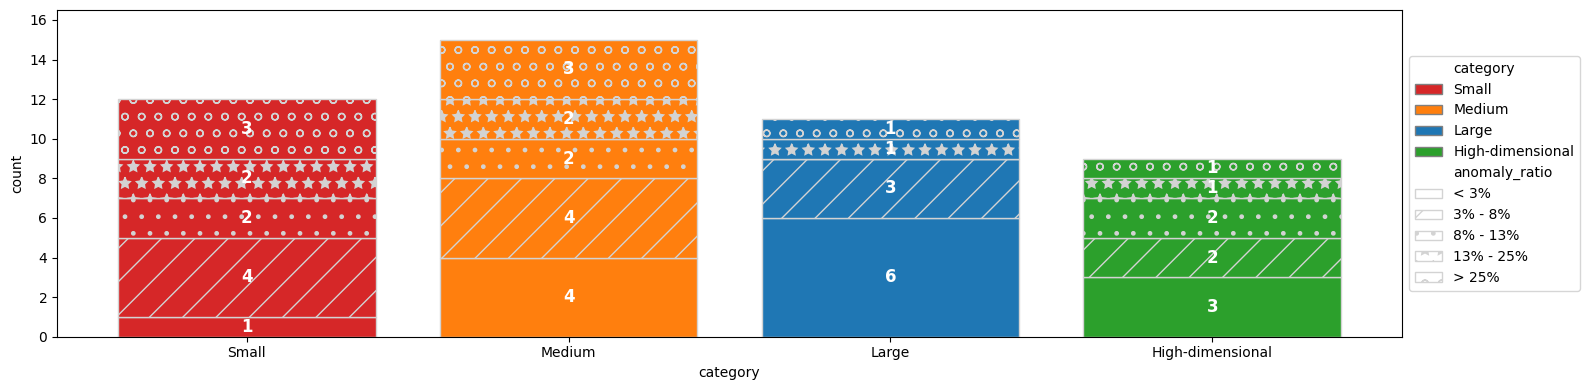

In [11]:
make_bar_plot(adbench_properties_df, "category", colors_category, color_col="category", rotation=0, legend=True, style_col="anomaly_ratio")

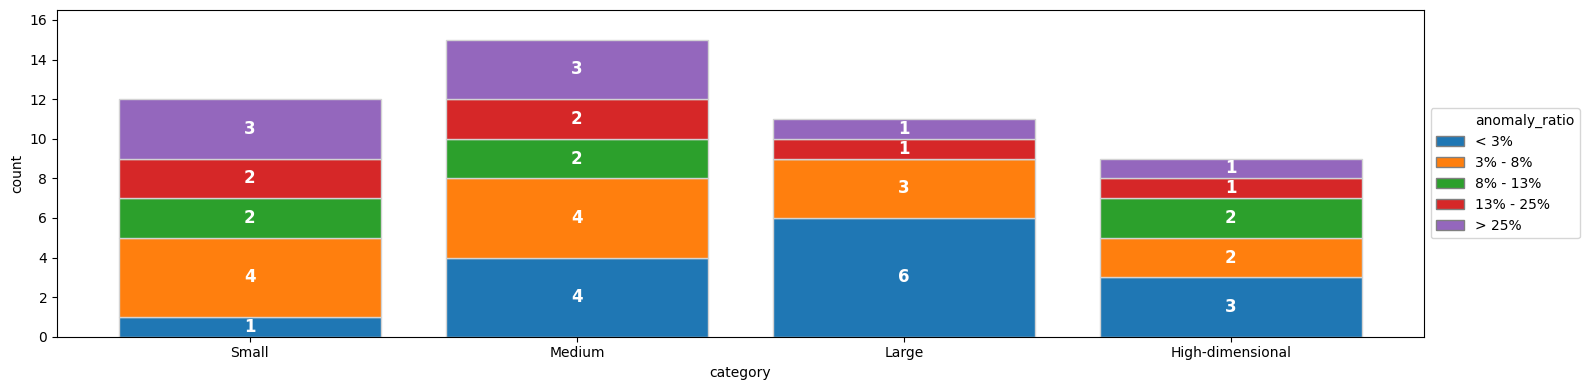

In [12]:
make_bar_plot(adbench_properties_df, "category", color_col="anomaly_ratio", rotation=0)

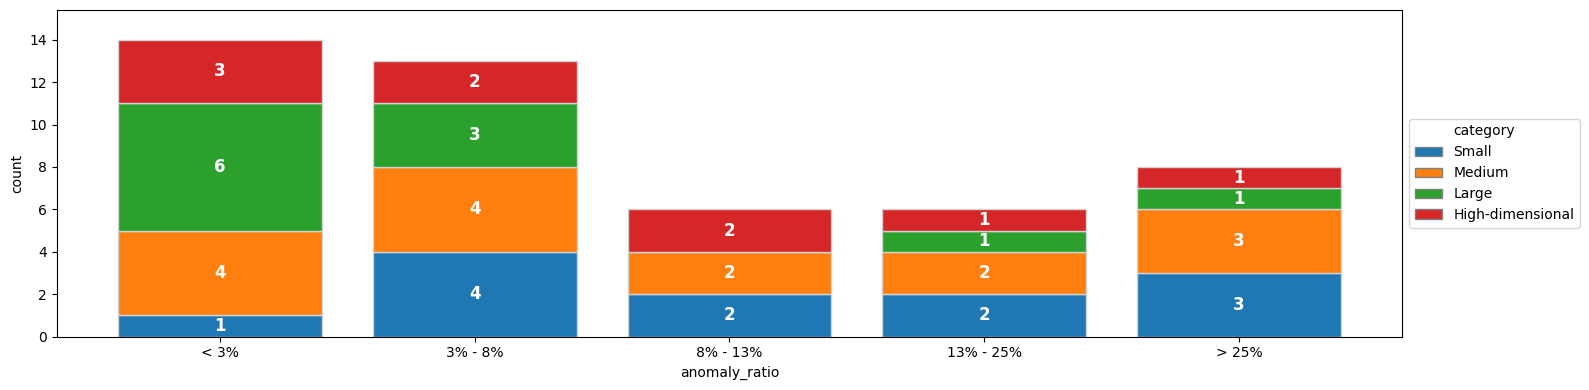

In [13]:
make_bar_plot(adbench_properties_df, "anomaly_ratio", color_col="category", rotation=0)

### Per Number of Samples

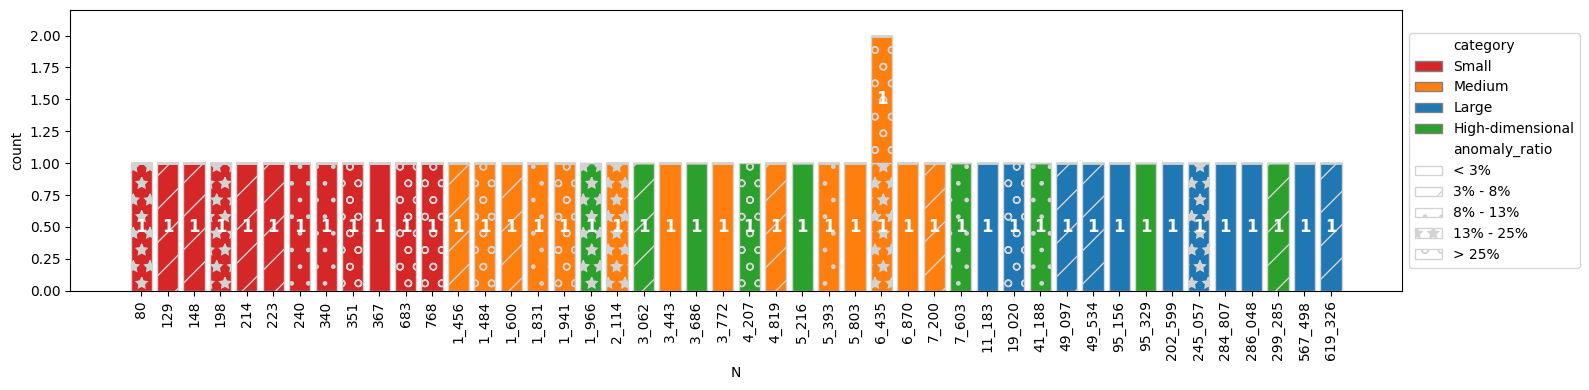

In [14]:
make_bar_plot(adbench_properties_df, "N", colors_category, color_col="category", format="_", style_col="anomaly_ratio")

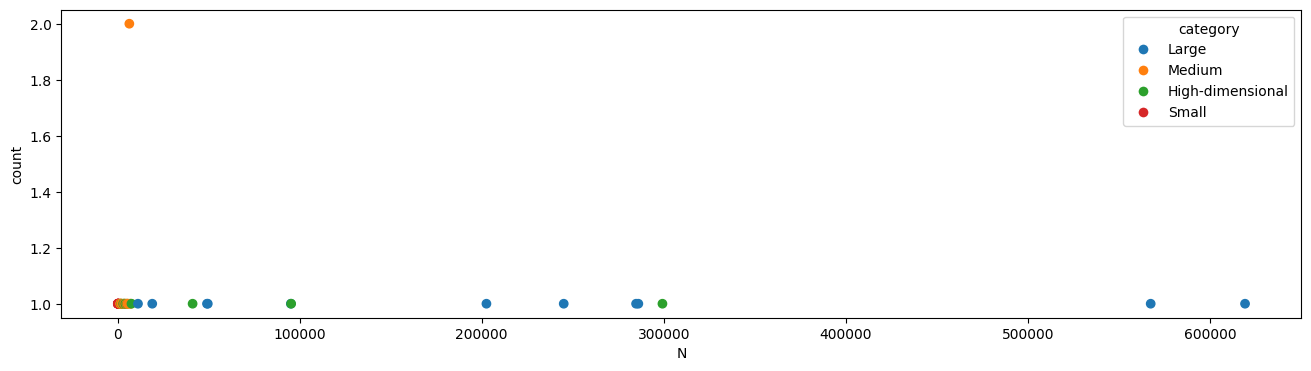

In [15]:
make_scatter_plot(adbench_properties_df, "N", colors_category)

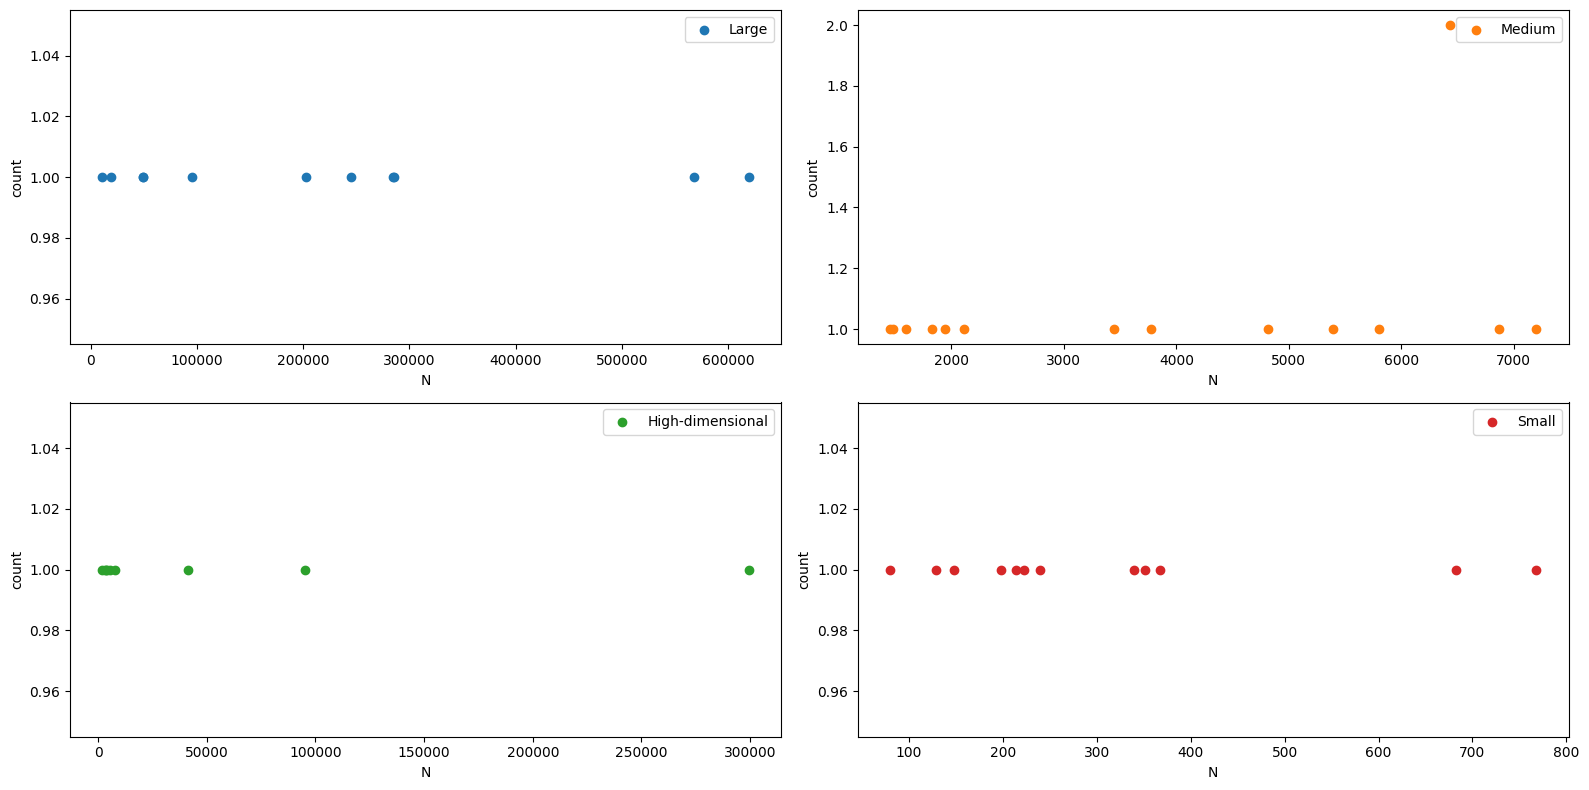

In [16]:
make_plot_per_category(adbench_properties_df, "N", colors_category)

### Per number of dimension

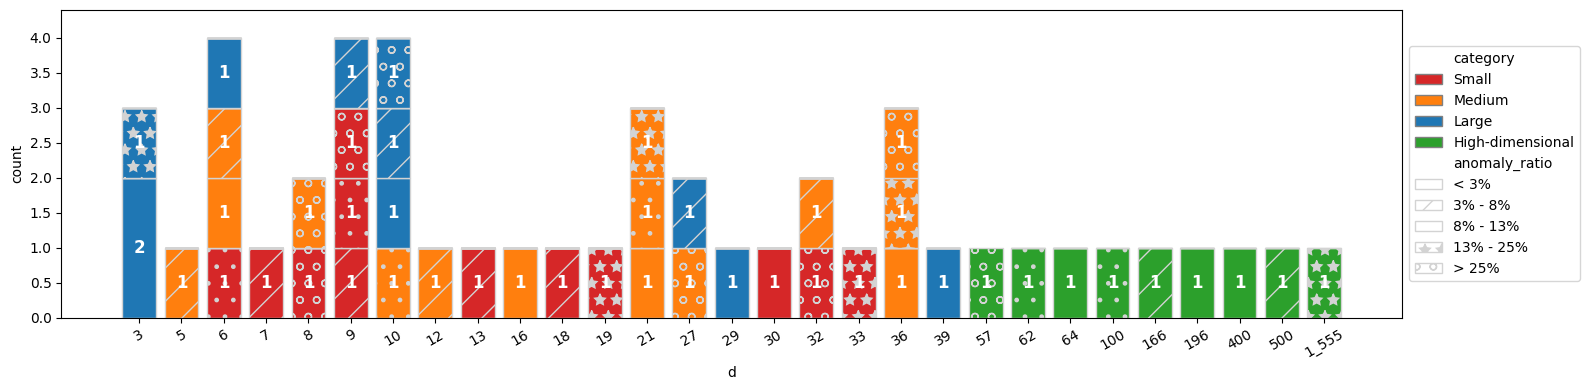

In [17]:
make_bar_plot(adbench_properties_df, "d", colors_category, color_col="category", style_col="anomaly_ratio", rotation=30, format="_")

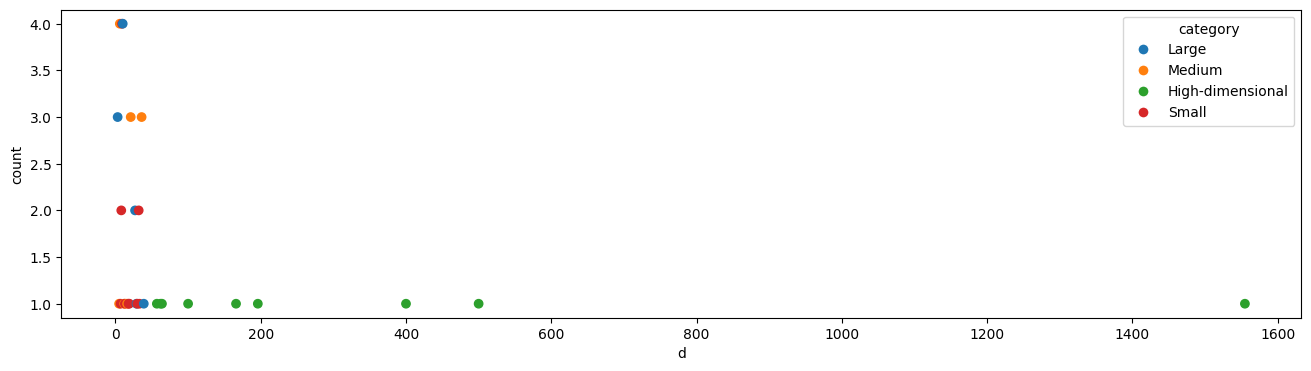

In [18]:
make_scatter_plot(adbench_properties_df, "d", colors_category)

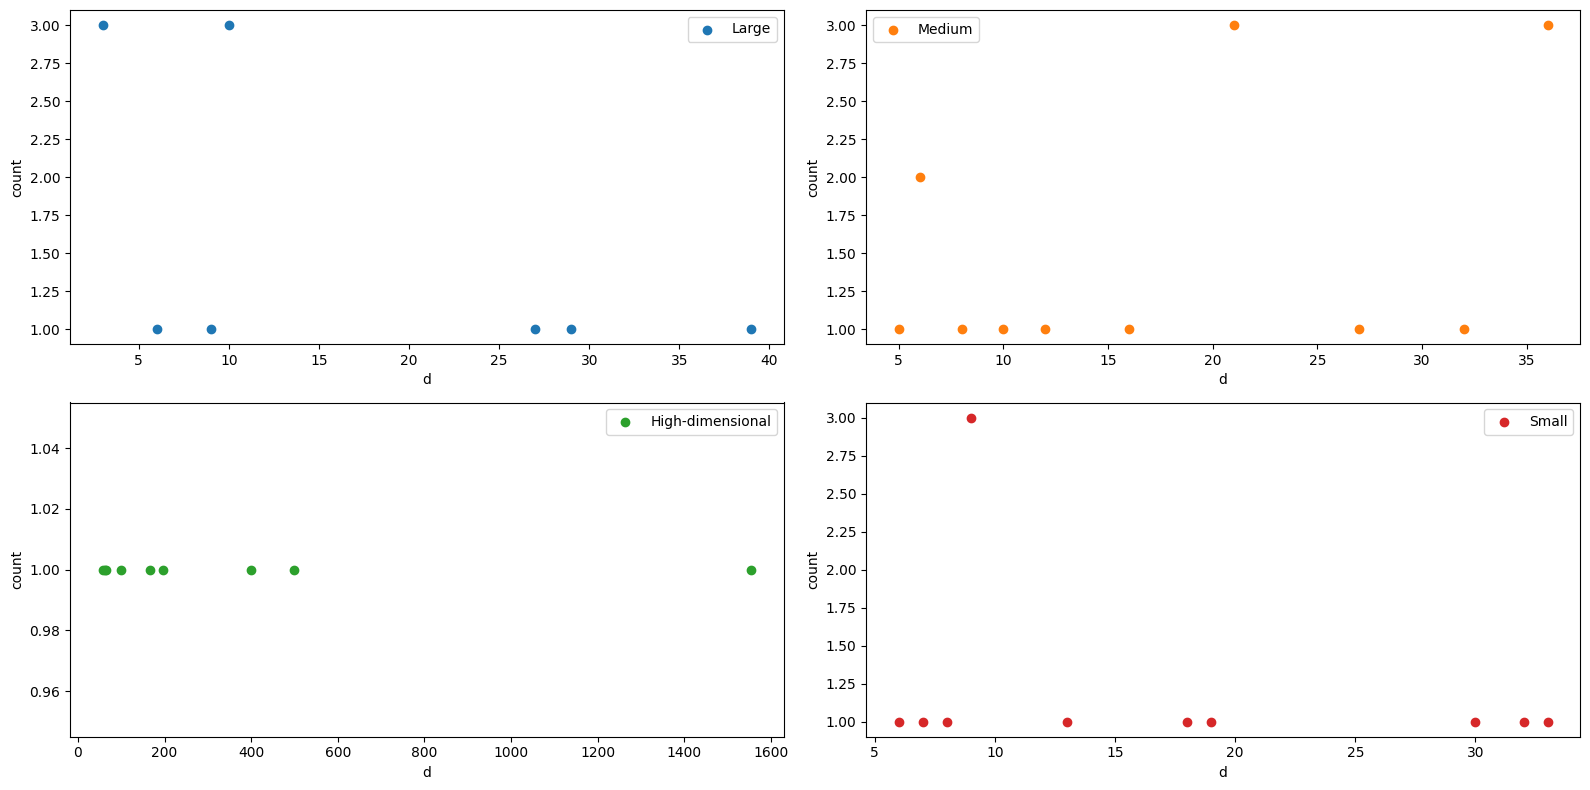

In [19]:
make_plot_per_category(adbench_properties_df, "d", colors_category)

### Per anomaly rate

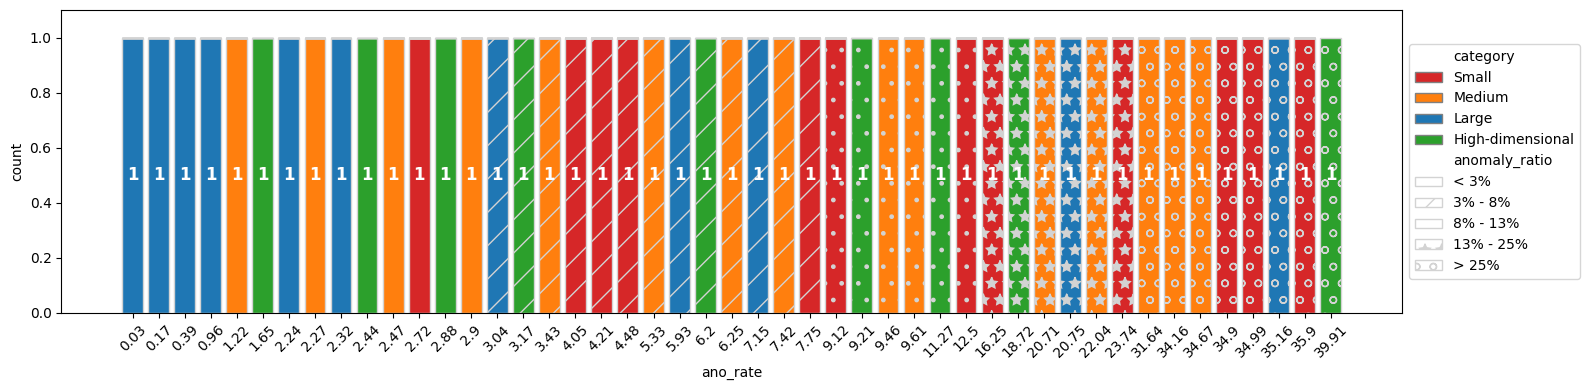

In [20]:
make_bar_plot(adbench_properties_df, "ano_rate", colors_category, color_col="category", style_col="anomaly_ratio", rotation=45)

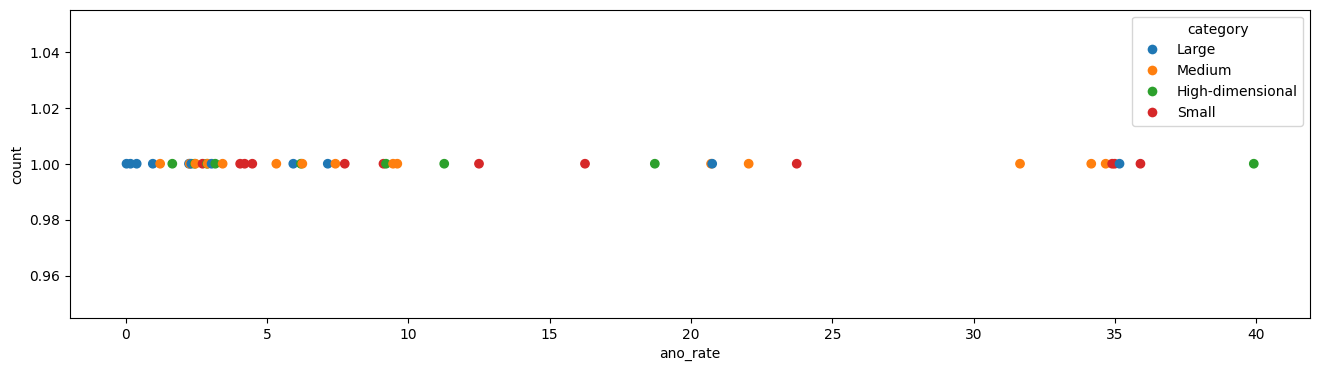

In [21]:
make_scatter_plot(adbench_properties_df, "ano_rate", colors_category)

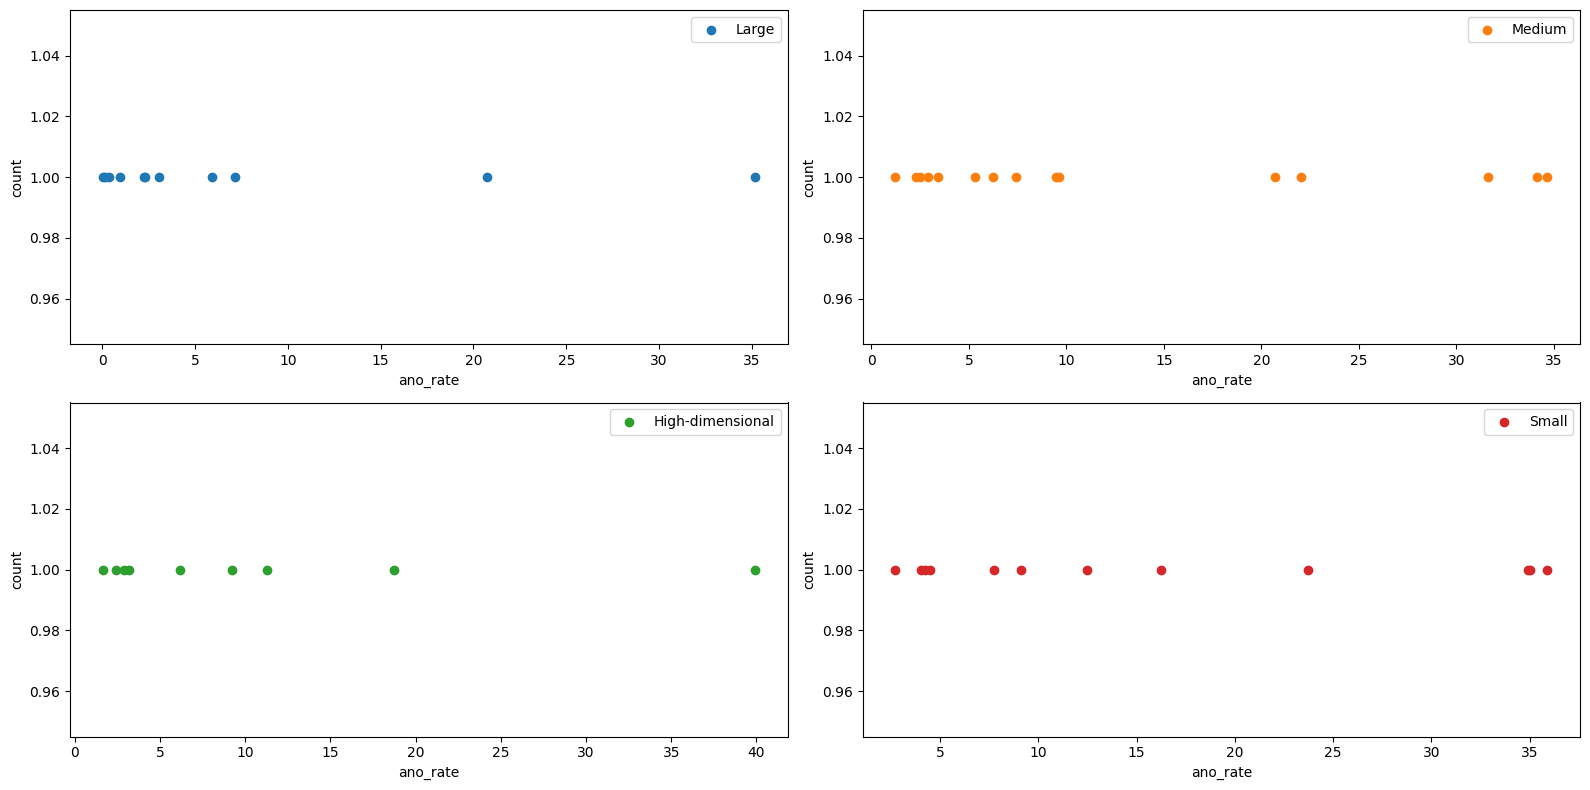

In [22]:
make_plot_per_category(adbench_properties_df, "ano_rate", colors_category)